# 07 · GRU predictions and residual analysis

The bidirectional GRU was the best performing of the five architectures, so this notebook uses it
alone, on Shannon diversity only. It does three things:

1. Trains the GRU with 5-fold cross-validation, repeated over 5 seeds.
2. Writes `merged_features_with_pred.csv` — the full feature table plus a `shannon_pred_gru`
   column, so no separate join is needed.
3. Computes residuals and plots autocorrelation for the combined, day-only and night-only series.

Every prediction is out-of-fold: made by a model that never saw that recording during training.
Each seed uses a different fold assignment, so averaging across seeds is still out-of-fold.

### The output file

`merged_features_with_pred.csv` is `merged_features.csv` with one column added:

`shannon_pred_gru` — the recording's predicted Shannon diversity, from clip predictions averaged
within a seed and then averaged across the 5 seeds. A recording-level value repeated across that
recording's clips, matching how the target behaves.

Values are joined by `recording_key`, not by row position, so the column is correct regardless of
row order. `merged_features.csv` itself is not modified.

Use `shannon_pred_gru` directly as an XGBoost input feature. Hand this file over as-is.

### Before running

Notebook 03 must have produced `merged_features.csv` and a spectrogram configuration.

In [1]:
# !pip install -q torch numpy pandas scipy matplotlib statsmodels

Configuration. `SEEDS_TO_RUN` controls how many repeats are averaged.

In [2]:
import os

BASE  = f"/scratch/{os.environ.get('USER','username')}/capstone"
MODEL_NAME = "bigru"

CONFIG         = "nfft1024_hop256"
TARGETS_TO_RUN = ["shannon_rare_no_anchoa"]
SEEDS_TO_RUN   = [0, 1, 2, 3, 4]

K_FOLDS  = 5
EPOCHS   = 40
BATCH    = 64
DROPOUT  = 0.5
WEIGHT_DECAY = 1e-2
NORM = "group"

VAL_FRAC  = 0.25
PATIENCE  = 10
WARMUP    = 5
MIN_DELTA = 0.01
SMOOTH    = 3
USE_SWA   = True
SWA_START = 6

LR_BY_ARCH  = {"bigru": 1e-4, "bilstm": 1e-4}
TIME_POOL   = 4
LSTM_HIDDEN = 64
ATTN_POOL   = True
DATA_TO_GPU = True

PERMUTE      = False
PERMUTE_SEED = 0

FEATURES_CSV = os.path.join(BASE, "merged_features.csv")
PREPARED     = os.path.join(BASE, "prepared")
RUNS         = os.path.join(BASE, "runs"); os.makedirs(RUNS, exist_ok=True)
FIG_DIR      = os.path.join(BASE, "figures", "gru"); os.makedirs(FIG_DIR, exist_ok=True)
PRED_COL     = "shannon_pred_gru"
PRED_CSV     = os.path.join(BASE, "merged_features_with_pred.csv")

LABELS = ["shannon_rare_no_anchoa"]
SHORT  = {"shannon_rare_no_anchoa": "shannon", "richness_rare_no_anchoa": "richness"}

print(f"model {MODEL_NAME} | config {CONFIG} | {len(SEEDS_TO_RUN)} seeds x {K_FOLDS} folds")

if USE_SWA and EPOCHS < SWA_START + 2:
    raise SystemExit(f"EPOCHS ({EPOCHS}) must exceed SWA_START ({SWA_START}) by at least 2, "
                     f"or weight averaging never engages.")
if EPOCHS <= WARMUP:
    raise SystemExit(f"EPOCHS ({EPOCHS}) must exceed WARMUP ({WARMUP}), "
                     f"or no epoch is eligible to be restored.")


model bigru | config nfft1024_hop256 | 5 seeds x 5 folds


In [3]:
import json
import numpy as np, pandas as pd

if not os.path.exists(FEATURES_CSV):
    raise SystemExit(f"{FEATURES_CSV} not found. Run 03_make_spectrograms.ipynb first.")
FEATURES = pd.read_csv(FEATURES_CSV,
                       usecols=lambda c: c in ({"recording_key"} | set(LABELS)))
PER_REC = FEATURES.groupby("recording_key")[LABELS].first()
print(f"targets from {os.path.basename(FEATURES_CSV)}: {PER_REC.shape[0]} recordings")

prep = os.path.join(PREPARED, CONFIG)
missing = [f for f in ["spectrograms.npy", "groups.npy", "meta.json"]
           if not os.path.exists(os.path.join(prep, f))]
if missing:
    raise SystemExit(f"{CONFIG} is missing {missing}")

targets from merged_features.csv: 72 recordings


In [4]:
import torch, torch.nn as nn, random
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


`load_config` selects the spectrogram configuration; `load_target` selects the target column from
the feature table.

In [5]:
spec = groups = meta = Y = None
rec_ids = rec_label = label_info = None
VALID_RECS = None
TARGET_SD = None
N = F = T = 0
CONFIG_NAME = PREP = TARGET = None
FREQ_MASK = TIME_MASK = 0

FREQ_MASK_FRAC = 0.20
TIME_MASK_FRAC = 0.15

def load_config(config_name, verbose=True):
    global spec, groups, meta, rec_ids, N, F, T
    global CONFIG_NAME, PREP, label_info, FREQ_MASK, TIME_MASK
    CONFIG_NAME = config_name
    PREP = os.path.join(PREPARED, config_name)
    try:
        arr = np.load(os.path.join(PREP, "spectrograms.npy"))
    except MemoryError:
        print("    (not enough RAM -- falling back to memory-mapped reads)")
        spec = np.load(os.path.join(PREP, "spectrograms.npy"), mmap_mode="r")
    else:
        spec = torch.from_numpy(arr)
        where = "RAM"
        if DATA_TO_GPU and device.type == "cuda":
            free, _ = torch.cuda.mem_get_info()
            if arr.nbytes < 0.4 * free:
                spec = spec.to(device); where = "VRAM"
        print(f"    spectrograms held in {where}")
    groups = np.load(os.path.join(PREP, "groups.npy"))
    meta   = json.load(open(os.path.join(PREP, "meta.json")))
    label_info = {}
    N, F, T = tuple(spec.shape)
    rec_ids = np.unique(groups)
    FREQ_MASK = max(1, int(round(FREQ_MASK_FRAC * F)))
    TIME_MASK = max(1, int(round(TIME_MASK_FRAC * T)))
    if verbose:
        print(f"config: {meta['config_name']} | {tuple(spec.shape)} | {N} clips, "
              f"{len(rec_ids)} recordings")

def load_target(target, verbose=True, permute=False, permute_seed=0):
    """Load one target column from the feature table, joined by recording name."""
    global Y, rec_label, TARGET, TARGET_SD, VALID_RECS
    if target not in PER_REC.columns:
        raise FileNotFoundError(f"{target} not in {os.path.basename(FEATURES_CSV)}")
    TARGET = target
    order = meta["rec_order"]
    absent = [r for r in order if r not in PER_REC.index]
    if absent:
        raise SystemExit(f"in the spectrogram cache but not in the CSV: {absent[:5]}")
    vals = PER_REC.loc[order, target].to_numpy(dtype=np.float32)
    if permute:
        vals = vals.copy(); np.random.default_rng(permute_seed).shuffle(vals)
    Y = vals[groups]
    rec_label = {int(r): float(vals[int(r)]) for r in rec_ids}
    VALID_RECS = np.array([int(r) for r in rec_ids if np.isfinite(rec_label[int(r)])])
    TARGET_SD = float(np.std([rec_label[int(r)] for r in VALID_RECS]))
    if verbose:
        v = np.array([rec_label[int(r)] for r in VALID_RECS])
        print(f"target '{target}': {v.min():.3f}-{v.max():.3f} | mean {v.mean():.3f} "
              f"| sd {v.std():.3f}")

load_config(CONFIG)
load_target(TARGETS_TO_RUN[0])

    spectrograms held in VRAM
config: nfft1024_hop256 | (2670, 324, 235) | 2670 clips, 72 recordings
target 'shannon_rare_no_anchoa': 0.699-2.171 | mean 1.334 | sd 0.372


Fold assignments are read from `runs/` if present, so this notebook tests on exactly the same splits
as notebooks 04 and 05.

In [6]:
def load_or_make_folds(seed, k=K_FOLDS, verbose=True):
    """Fold index for each recording, read from a shared file in `runs/` or created on first use."""
    p = os.path.join(RUNS, f"folds_k{k}_seed{seed}.json")
    rec_order = meta["rec_order"]
    ids = VALID_RECS if VALID_RECS is not None else rec_ids
    if os.path.exists(p):
        d = json.load(open(p))
        miss = [rec_order[int(r)] for r in ids if rec_order[int(r)] not in d["folds"]]
        if miss:
            raise SystemExit(f"{p} does not cover: {miss[:3]} ... delete it to regenerate.")
        return np.array([d["folds"][rec_order[int(r)]] for r in ids], dtype=int)
    rng = np.random.default_rng(seed)
    ids = np.asarray(ids).copy(); rng.shuffle(ids)
    assign = {}
    for f, part in enumerate(np.array_split(ids, k)):
        for r in part:
            assign[rec_order[int(r)]] = f
    json.dump(dict(k=k, seed=seed, n_recordings=len(assign), folds=assign),
              open(p, "w"), indent=2)
    if verbose:
        print(f"    wrote shared fold file -> {os.path.basename(p)}")
    ids2 = VALID_RECS if VALID_RECS is not None else rec_ids
    return np.array([assign[rec_order[int(r)]] for r in ids2], dtype=int)

In [7]:
AUGMENT = True
NOISE   = 0.15         # Gaussian noise added to standardized input
N_MASKS = 2            # masks per axis, as in SpecAugment

def augment(x):
    """SpecAugment-style masking plus Gaussian noise, N_MASKS times per axis."""
    if NOISE > 0: x = x + NOISE * torch.randn_like(x)
    Fd, Td = x.shape[-2], x.shape[-1]
    for _ in range(N_MASKS):
        if FREQ_MASK > 0:
            f = random.randint(0, min(FREQ_MASK, Fd)); f0 = random.randint(0, max(0, Fd - f))
            x[..., f0:f0+f, :] = 0.0
        if TIME_MASK > 0:
            t = random.randint(0, min(TIME_MASK, Td)); t0 = random.randint(0, max(0, Td - t))
            x[..., :, t0:t0+t] = 0.0
    return x

def batches(idx, bs, shuffle, s_mu, s_sd, t_mu, t_sd):
    """Yield (x, y, sel) batches by slicing the in-memory array.

    `sel` is returned so callers scatter predictions by index rather than by batch order."""
    idx = np.asarray(idx)
    order = np.random.permutation(len(idx)) if shuffle else np.arange(len(idx))
    sel_all = idx[order]
    for k in range(0, len(sel_all), bs):
        sel = sel_all[k:k+bs]
        if torch.is_tensor(spec):
            x = spec.index_select(0, torch.as_tensor(sel, device=spec.device))
            x = x.to(device, non_blocking=True).float()
        else:
            sel = np.sort(sel)                      # contiguous-ish reads for the memmap path
            x = torch.from_numpy(np.asarray(spec[sel], dtype=np.float32)).to(device)
        x = ((x - s_mu) / s_sd).unsqueeze(1)         # (B, 1, F, T)
        y = torch.from_numpy(((Y[sel] - t_mu) / t_sd).astype(np.float32)).to(device)
        yield x, y, sel

The model is the same bidirectional GRU used in notebook 05.

In [8]:
class AttnPool(nn.Module):
    """Softmax-weighted average over time (Ilse et al., 2018, gated attention MIL).

    Scores each timestep with a small tanh MLP, softmaxes the scores into weights, and returns the
    weighted sum. Reduces to a plain mean when all scores are equal, so it cannot do worse than
    mean pooling by construction -- it can only learn to be more selective."""
    def __init__(self, d, hidden=64):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(d, hidden), nn.Tanh(), nn.Linear(hidden, 1))
    def forward(self, h):                              # (B, T, D) -> (B, D), (B, T)
        w = torch.softmax(self.score(h).squeeze(-1), dim=1)
        return (w.unsqueeze(-1) * h).sum(1), w

class RecurrentNet(nn.Module):
    """Average-pool time, run a bidirectional RNN, aggregate over steps, then the shared head.

    `cell` picks the recurrent unit. An LSTM keeps a separate cell state behind four gates; a GRU
    merges that into the hidden state with three, so it has ~25% fewer parameters at the same
    hidden size. Aggregation is attention-weighted when ATTN_POOL is on, otherwise a plain mean."""
    def __init__(self, n_freq, cell="lstm", p=0.5, pool=TIME_POOL, hid=LSTM_HIDDEN):
        super().__init__()
        self.pool = nn.AvgPool1d(pool)
        rnn = nn.LSTM if cell == "lstm" else nn.GRU
        self.rnn  = rnn(n_freq, hid, batch_first=True, bidirectional=True)
        self.attn = AttnPool(hid*2) if ATTN_POOL else None
        self.norm = nn.LayerNorm(hid*2); self.drop = nn.Dropout(p)
        self.head = nn.Sequential(nn.Linear(hid*2,128), nn.ReLU(), nn.Dropout(p), nn.Linear(128,1))
    def forward(self, x):                              # x: (B, 1, F, T)
        xf = self.pool(x.squeeze(1)).transpose(1, 2)   # (B, T', F) -- one step per time frame
        out, _ = self.rnn(xf)
        z = self.attn(out)[0] if self.attn is not None else out.mean(1)
        return self.head(self.drop(self.norm(z))).squeeze(-1)


class BiLSTM(RecurrentNet):
    def __init__(self, p=0.5): super().__init__(F, "lstm", p)

class BiGRU(RecurrentNet):
    def __init__(self, p=0.5): super().__init__(F, "gru", p)
ARCHS = {"bigru": BiGRU, "bilstm": BiLSTM}

def build_net(arch): return ARCHS[arch](DROPOUT).to(device)
def n_params(arch):  return sum(p.numel() for p in ARCHS[arch](DROPOUT).parameters())

print(f"{MODEL_NAME}: {n_params(MODEL_NAME):,d} parameters | {F} bins per step | "
      f"{T} frames -> {T // TIME_POOL} steps after pooling")

bigru: 174,978 parameters | 324 bins per step | 235 frames -> 58 steps after pooling


## Cross-validation

Identical to notebooks 04 and 05. `run_cv` also returns the clip-level out-of-fold predictions,
which is what this notebook exports.

In [9]:
def r2_score(y, p, ref_sd=None):
    """R2 for one fold.

    Returns nan when the fold spans less than 5% of the target's overall spread: the denominator
    is then too small for the ratio to be meaningful."""
    y = np.asarray(y, float); p = np.asarray(p, float)
    if y.size < 2: return float("nan")
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    if ss_tot <= 0: return float("nan")
    if ref_sd is not None and ref_sd > 0 and float(np.std(y)) < 0.05 * ref_sd:
        return float("nan")
    return 1.0 - float(np.sum((y - p) ** 2)) / ss_tot

def metrics(true, pred, ref_sd=None):
    """MAE, RMSE and R2. MAE and RMSE are in the target's own units."""
    true = np.asarray(true, float); pred = np.asarray(pred, float)
    return dict(mae=float(np.abs(pred-true).mean()),
                rmse=float(np.sqrt(np.mean((pred-true)**2))),
                r2=r2_score(true, pred, ref_sd=ref_sd))

_STATS_CACHE = {}

def spec_mean_std(idx, key=None, chunk=512):
    """Mean and standard deviation over a set of clips.

    Cached by (config, seed, fold): the value depends only on which recordings are in the fit
    split, not on the architecture or target."""
    if key is not None and key in _STATS_CACHE:
        return _STATS_CACHE[key]
    idx = np.asarray(idx); tot = sq = 0.0; cnt = 0
    for i in range(0, len(idx), chunk):
        sel = idx[i:i+chunk]
        if torch.is_tensor(spec):
            blk = spec.index_select(0, torch.as_tensor(sel, device=spec.device)).double()
            tot += float(blk.sum()); sq += float((blk**2).sum()); cnt += blk.numel()
        else:
            blk = np.asarray(spec[np.sort(sel)], dtype=np.float64)
            tot += blk.sum(); sq += (blk**2).sum(); cnt += blk.size
    mu = tot/cnt
    out = (float(mu), float(np.sqrt(max(sq/cnt - mu*mu, 0.0)) + 1e-6))
    if key is not None: _STATS_CACHE[key] = out
    return out

def train_fold(arch, fit_idx, val_idx, te_idx, seed, stats_key=None):
    s_mu, s_sd = spec_mean_std(fit_idx, key=stats_key)
    t_mu, t_sd = float(Y[fit_idx].mean()), float(Y[fit_idx].std() + 1e-6)
    mk = lambda ix, sh: (lambda: batches(ix, BATCH, sh, s_mu, s_sd, t_mu, t_sd))
    tr_dl, va_dl, te_dl = mk(fit_idx, True), mk(val_idx, False), mk(te_idx, False)

    torch.manual_seed(seed); net = build_net(arch)
    opt  = torch.optim.AdamW(net.parameters(), lr=LR_BY_ARCH.get(arch, 3e-4),
                             weight_decay=WEIGHT_DECAY)
    crit = nn.SmoothL1Loss()
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, "min", factor=0.5, patience=3)

    def predict(fn):
        """Returns predictions in REAL units plus the clip indices they belong to, so callers
        scatter by index rather than trusting batch order."""
        net.eval(); P, I = [], []
        with torch.no_grad():
            for x, y, sel in fn():
                P.append(net(x).cpu().numpy()); I.append(sel)
        return np.concatenate(P)*t_sd + t_mu, np.concatenate(I)

    hist = {"epoch": [], "train_loss": [], "val_mae": [], "val_mae_smooth": [],
            "val_mae_std": [], "lr": []}
    best = float("inf"); bad = 0; best_state = None; best_ep = 0; stopped_early = False
    min_delta_abs = MIN_DELTA * t_sd          # relative threshold -> absolute, in label units
    swa_state, swa_n = None, 0                # running mean of weights from SWA_START onward

    for ep in range(1, EPOCHS + 1):
        net.train(); run = 0.0; nb = 0
        for x, y, _ in tr_dl():
            if AUGMENT: x = augment(x)
            opt.zero_grad(); loss = crit(net(x), y); loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0); opt.step()
            run += float(loss.item()); nb += 1
        Pv, Iv = predict(va_dl); v = float(np.abs(Pv - Y[Iv]).mean())
        sched.step(v)
        hist["epoch"].append(ep); hist["train_loss"].append(run/max(1,nb))
        hist["val_mae"].append(v)
        # smoothed criterion: the mean of the last SMOOTH epochs, so a single lucky epoch cannot
        # win the "best" slot on its own
        vs = float(np.mean(hist["val_mae"][-SMOOTH:]))
        hist["val_mae_smooth"].append(vs)
        hist["val_mae_std"].append(vs / t_sd)
        hist["lr"].append(float(opt.param_groups[0]["lr"]))

        if USE_SWA and ep >= SWA_START:
            sd_now = net.state_dict()
            if swa_state is None:
                swa_state = {k: v.detach().clone().float() for k, v in sd_now.items()}
                swa_n = 1
            else:
                swa_n += 1
                for k, v in sd_now.items():
                    if swa_state[k].is_floating_point():
                        swa_state[k] += (v.detach().float() - swa_state[k]) / swa_n
                    else:
                        swa_state[k] = v.detach().clone()

        if ep < WARMUP:
            continue                          # too early to judge; also never restore these weights
        if vs < best - min_delta_abs:         # must beat the incumbent by a real margin
            best, bad, best_ep = vs, 0, ep
            best_state = {k: t.clone() for k, t in net.state_dict().items()}
        else:
            bad += 1
            if bad >= PATIENCE: stopped_early = True; break

    used = "best_epoch"
    if USE_SWA and swa_state is not None and swa_n > 1:
        net.load_state_dict({k: v.to(dtype=net.state_dict()[k].dtype)
                             for k, v in swa_state.items()})
        # BatchNorm running statistics no longer match the averaged weights, so re-estimate them.
        # GroupNorm holds no running statistics and needs nothing.
        if NORM == "batch":
            for mod in net.modules():
                if isinstance(mod, nn.BatchNorm2d):
                    mod.reset_running_stats(); mod.momentum = None
            net.train()
            with torch.no_grad():
                for x, _, _ in tr_dl():
                    net(x)
        used = f"swa({swa_n} epochs)"
    elif best_state is not None:
        net.load_state_dict(best_state)
    pred_te, idx_te = predict(te_dl)
    stop = dict(epochs_run=hist["epoch"][-1], best_epoch=best_ep, epoch_cap=EPOCHS,
                early_stopped=bool(stopped_early), patience=PATIENCE,
                warmup=WARMUP, min_delta_frac=MIN_DELTA, smooth=SMOOTH,
                weights_used=used, swa_epochs=int(swa_n),
                val_recordings=int(len(np.unique(groups[val_idx]))),
                best_val_mae=float(best), reason=("early stop" if stopped_early else "epoch cap"))
    fit_vals = [rec_label[int(r)] for r in np.unique(groups[fit_idx])]
    return pred_te, idx_te, float(np.mean(fit_vals)), float(np.median(fit_vals)), hist, stop

In [10]:
def run_cv(arch, seed, verbose=True):
    fold_of = load_or_make_folds(seed, K_FOLDS, verbose=verbose)
    scored = VALID_RECS if VALID_RECS is not None else rec_ids
    clip_pred = np.full(N, np.nan)
    rec_pred, base_mean, base_med = {}, {}, {}
    per_fold, histories, stops = [], [], []

    for f in range(K_FOLDS):
        te_recs = scored[fold_of == f]
        tr_recs = scored[fold_of != f]
        rf = np.random.default_rng(1000 + f); tr_recs = tr_recs.copy(); rf.shuffle(tr_recs)
        n_val = max(2, int(round(VAL_FRAC * len(tr_recs))))
        val_recs, fit_recs = tr_recs[:n_val], tr_recs[n_val:]

        fit_idx = np.where(np.isin(groups, fit_recs))[0]
        val_idx = np.where(np.isin(groups, val_recs))[0]
        te_idx  = np.where(np.isin(groups, te_recs))[0]

        preds, idx_te, mu, med, hist, stop = train_fold(
            arch, fit_idx, val_idx, te_idx, seed*100 + f,
            stats_key=(CONFIG_NAME, seed, f))
        clip_pred[idx_te] = preds
        for r in te_recs:
            ci = np.where(groups == r)[0]
            rec_pred[int(r)]  = float(np.nanmean(clip_pred[ci]))
            base_mean[int(r)] = mu; base_med[int(r)] = med

        m = metrics([rec_label[int(r)] for r in te_recs],
                    [rec_pred[int(r)] for r in te_recs], ref_sd=TARGET_SD)
        per_fold.append(m); histories.append(hist); stops.append(stop)
        if verbose:
            tag = "EARLY STOP" if stop["early_stopped"] else "EPOCH CAP "
            print(f"    fold {f+1}/{K_FOLDS}: test={len(te_recs):2d} | "
                  f"ran {stop['epochs_run']:2d}/{EPOCHS} | best@{stop['best_epoch']:2d} | {tag} | "
                  f"MAE={m['mae']:.4f} RMSE={m['rmse']:.4f} R2={m['r2']:.3f}")

    recs  = list(rec_pred)
    truth = [rec_label[r] for r in recs]
    rec_m  = metrics(truth, [rec_pred[r]  for r in recs], ref_sd=TARGET_SD)
    b_mean = metrics(truth, [base_mean[r] for r in recs], ref_sd=TARGET_SD)
    b_med  = metrics(truth, [base_med[r]  for r in recs], ref_sd=TARGET_SD)

    if verbose:
        ne = sum(s["early_stopped"] for s in stops)
        eps = [s["epochs_run"] for s in stops]; bst = [s["best_epoch"] for s in stops]
        print(f"    stopping: {ne}/{K_FOLDS} early-stopped, {K_FOLDS-ne}/{K_FOLDS} hit the cap | "
              f"epochs {min(eps)}/{int(np.median(eps))}/{max(eps)} | "
              f"best {min(bst)}/{int(np.median(bst))}/{max(bst)}")
        print(f"    validation split: {stops[0]['val_recordings']} recordings per fold | "
              f"weights: {stops[0]['weights_used']}")
        if ne < K_FOLDS:
            print(f"    NOTE: {K_FOLDS-ne} fold(s) still improving at epoch {EPOCHS}.")
        if not USE_SWA:
            if min(bst) < WARMUP + 2:
                print(f"    NOTE: a fold restored weights from epoch {min(bst)}, barely past warmup "
                      f"-- the validation signal may be too noisy to select on.")
            if max(bst) - min(bst) > 12:
                print(f"    NOTE: best epoch ranges {min(bst)}-{max(bst)} across folds. A tight "
                      f"cluster would suggest a real optimum; this much scatter suggests there is "
                      f"little to learn beyond the mean.")

    return dict(clip_pred=clip_pred, per_fold=per_fold, rec=rec_m, base_mean=b_mean,
                base_median=b_med,
                n_rec=len(recs), histories=histories, stops=stops,
                rec_pred=rec_pred, rec_true={int(r): rec_label[int(r)] for r in recs},
                fold_of={int(r): int(fold_of[i]) for i, r in enumerate(scored)})

## Run

In [11]:
import time, traceback

pred_clip = {}
summary   = []
t_start   = time.time()
job = 0
n_jobs = len(TARGETS_TO_RUN) * len(SEEDS_TO_RUN)

load_config(CONFIG, verbose=False)
for target in TARGETS_TO_RUN:
    for seed in SEEDS_TO_RUN:
        job += 1
        print(f"\n[{job}/{n_jobs}] {MODEL_NAME} -> {target} | seed={seed}", flush=True)
        load_target(target, verbose=False, permute=PERMUTE, permute_seed=PERMUTE_SEED + seed)
        t0 = time.time()
        try:
            res = run_cv(MODEL_NAME, seed)
        except Exception:
            print("    FAILED:"); traceback.print_exc(limit=2); continue
        mins = (time.time() - t0) / 60
        pred_clip[(target, seed)] = res["clip_pred"].copy()
        h, bmu, bmd = res["rec"], res["base_mean"], res["base_median"]
        print(f"    POOLED: MAE={h['mae']:.4f} (mean-base {bmu['mae']:.4f}, "
              f"median-base {bmd['mae']:.4f}) | RMSE={h['rmse']:.4f} | R2={h['r2']:.3f} "
              f"| {mins:.1f} min")
        summary.append(dict(target=target, seed=seed, MAE=h["mae"], RMSE=h["rmse"], R2=h["r2"],
                            MAE_mean_base=bmu["mae"], MAE_median_base=bmd["mae"],
                            minutes=round(mins, 1)))

S = pd.DataFrame(summary)
print(f"\n{'='*70}\n{len(S)} run(s) in {(time.time()-t_start)/60:.1f} min\n{'='*70}")
if len(S):
    with pd.option_context("display.float_format", lambda v: f"{v:.4f}"):
        print(S.to_string(index=False))
    print(f"\nmean over seeds: R2 {S['R2'].mean():.4f} +/- {S['R2'].std():.4f} | "
          f"MAE {S['MAE'].mean():.4f} +/- {S['MAE'].std():.4f} | "
          f"RMSE {S['RMSE'].mean():.4f} +/- {S['RMSE'].std():.4f}")

    spectrograms held in VRAM

[1/5] bigru -> shannon_rare_no_anchoa | seed=0
    fold 1/5: test=15 | ran 18/40 | best@ 8 | EARLY STOP | MAE=0.2458 RMSE=0.3074 R2=0.217
    fold 2/5: test=15 | ran 15/40 | best@ 5 | EARLY STOP | MAE=0.2649 RMSE=0.3290 R2=0.160
    fold 3/5: test=14 | ran 15/40 | best@ 5 | EARLY STOP | MAE=0.3035 RMSE=0.3519 R2=0.140
    fold 4/5: test=14 | ran 19/40 | best@ 9 | EARLY STOP | MAE=0.2911 RMSE=0.3481 R2=0.151
    fold 5/5: test=14 | ran 32/40 | best@22 | EARLY STOP | MAE=0.2452 RMSE=0.3233 R2=0.121
    stopping: 5/5 early-stopped, 0/5 hit the cap | epochs 15/18/32 | best 5/8/22
    validation split: 14 recordings per fold | weights: swa(13 epochs)
    POOLED: MAE=0.2697 (mean-base 0.3078, median-base 0.3073) | RMSE=0.3320 | R2=0.202 | 0.2 min

[2/5] bigru -> shannon_rare_no_anchoa | seed=1
    fold 1/5: test=15 | ran 23/40 | best@13 | EARLY STOP | MAE=0.2668 RMSE=0.3237 R2=-0.386
    fold 2/5: test=15 | ran 28/40 | best@18 | EARLY STOP | MAE=0.2876 RMSE=0.3

## Write the output file

The feature table is read, `shannon_pred_gru` is joined on by `recording_key`, and the result is
written to a new file. The original `merged_features.csv` is left untouched.

In [12]:
rec_order = meta["rec_order"]
keys = [rec_order[g] for g in groups]

TARGET_COL = TARGETS_TO_RUN[0]
tag = SHORT[TARGET_COL]
seeds = [sd for sd in SEEDS_TO_RUN if (TARGET_COL, sd) in pred_clip]
if not seeds:
    raise SystemExit("no predictions were produced")

# clip predictions -> one value per recording per seed -> mean and sd across seeds
per_seed = {sd: pd.DataFrame({"k": keys, "p": pred_clip[(TARGET_COL, sd)]})
                  .groupby("k")["p"].mean() for sd in seeds}
R = pd.DataFrame(per_seed)
REC_PRED = R.mean(axis=1)
REC_SD   = R.std(axis=1) if len(seeds) > 1 else pd.Series(0.0, index=R.index)

MF = pd.read_csv(FEATURES_CSV)
n_before = MF.shape[1]
MF[PRED_COL] = MF["recording_key"].map(REC_PRED)

unmatched = int(MF[PRED_COL].isna().sum())
if unmatched:
    miss = sorted(MF.loc[MF[PRED_COL].isna(), "recording_key"].unique())[:5]
    print(f"[export] WARNING: {unmatched} row(s) have no prediction: {miss}")

MF.to_csv(PRED_CSV, index=False)
print(f"[export] {os.path.relpath(PRED_CSV, BASE)}")
print(f"         {len(MF)} rows | {MF['recording_key'].nunique()} recordings | "
      f"{n_before} -> {MF.shape[1]} columns | {os.path.getsize(PRED_CSV)/1e6:.1f} MB")
print(f"         {os.path.basename(FEATURES_CSV)} was not modified")
print()
print(f"{PRED_COL}: {REC_PRED.min():.3f}-{REC_PRED.max():.3f} | mean {REC_PRED.mean():.3f}")
print(f"   seed-to-seed sd of the prediction: {REC_SD.mean():.4f}")
print(f"   actual mean: {PER_REC[TARGET_COL].mean():.3f}")
print()
print(f"Send {os.path.basename(PRED_CSV)} as-is. No separate join is needed.")

# kept in memory for the residual analysis below; not written to disk
P = pd.DataFrame({"recording_key": keys})
P["date"]        = P["recording_key"].str.split().str[0]
P["collection"]  = P["recording_key"].str.split().str[1].str.lower()
P[f"{tag}_actual"]   = P["recording_key"].map(PER_REC[TARGET_COL])
P[f"{tag}_pred"]     = P["recording_key"].map(REC_PRED)
P[f"{tag}_pred_sd"]  = P["recording_key"].map(REC_SD)
P[f"{tag}_residual"] = P[f"{tag}_actual"] - P[f"{tag}_pred"]

[export] merged_features_with_pred.csv
         2670 rows | 72 recordings | 116 -> 117 columns | 2.5 MB
         merged_features.csv was not modified

shannon_pred_gru: 1.062-1.668 | mean 1.300
   seed-to-seed sd of the prediction: 0.0845
   actual mean: 1.334

Send merged_features_with_pred.csv as-is. No separate join is needed.


/tmp/ipykernel_336419/4099292083.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  MF[PRED_COL] = MF["recording_key"].map(REC_PRED)


## Residuals

Residual = actual minus predicted, one per recording. Correlated errors would mean the model is
missing something that varies with the calendar, and that random cross-validation is optimistic.

Three series are used:

- **Combined** — one residual per date, day and night averaged where both were recorded (42 points)
- **Day** — day sessions only (33 points)
- **Night** — night sessions only (39 points)

Autocorrelation is computed on the residuals **in time order**, so lag 1 is the step to the next
recording in the series. Sampling was weekly for 80% of consecutive pairs, so lag 1 is close to one
week and lag 4 close to one month. The correspondence loosens at longer lags as missed weeks
accumulate; the table below reports what each lag actually spans.

In [13]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

REC = P.groupby("recording_key").first().reset_index()
REC["date"] = pd.to_datetime(REC["date"])
RESID = f"{tag}_residual"

def obs_series(which):
    """Residuals in time order. `which` is All, Day or Night.

    For the combined series a date contributes one residual: where both a day and a night session
    were recorded, the two are averaged, so lag 1 is always a step to the next date rather than
    alternating between an eight-hour and a week-long step."""
    d = REC.dropna(subset=[RESID])
    if which == "All":
        return d.groupby("date")[RESID].mean().sort_index()
    return d[d["collection"] == which.lower()].set_index("date")[RESID].sort_index()

SERIES = {w: obs_series(w) for w in ["All", "Day", "Night"]}
print(f"{'series':8s} {'n':>4s} {'mean':>9s} {'sd':>8s}   median days spanned by each lag")
for w, s in SERIES.items():
    if len(s) < 8: continue
    dts = pd.Series(s.index)
    txt = "  ".join(f"lag{L}={float((dts.shift(-L)-dts).dt.days.dropna().median()):.0f}d"
                    for L in [1, 2, 4, 8] if L < len(s))
    print(f"{w:8s} {len(s):>4d} {s.mean():>9.4f} {s.std():>8.4f}   {txt}")

series      n      mean       sd   median days spanned by each lag
All        42    0.0273   0.3121   lag1=7d  lag2=14d  lag4=35d  lag8=70d
Day        33   -0.0180   0.2941   lag1=7d  lag2=14d  lag4=35d  lag8=91d
Night      39    0.0786   0.3498   lag1=7d  lag2=14d  lag4=37d  lag8=77d


Residuals over time.

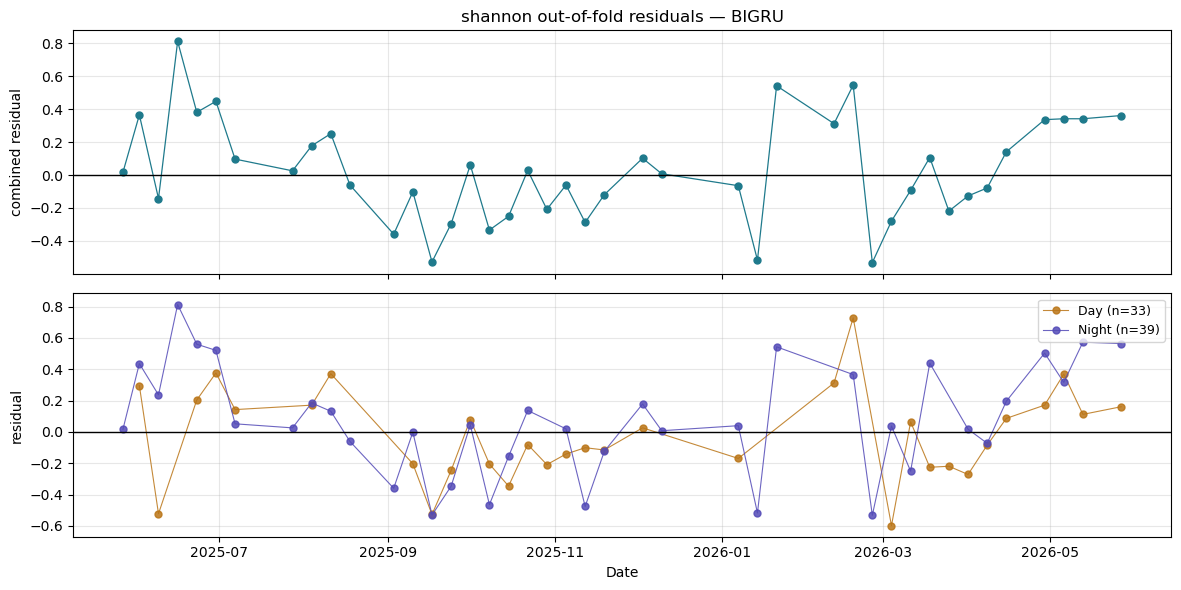

In [14]:
COLS = {"All": "#1F7A8C", "Day": "#BA7517", "Night": "#534AB7"}
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
s = SERIES["All"]
axes[0].plot(s.index, s.values, "o-", ms=5, lw=0.9, color=COLS["All"])
axes[0].axhline(0, color="k", lw=1); axes[0].grid(alpha=0.3)
axes[0].set_ylabel("combined residual")
axes[0].set_title(f"{tag} out-of-fold residuals — {MODEL_NAME.upper()}", fontsize=12)
for w in ["Day", "Night"]:
    s = SERIES[w]
    if len(s):
        axes[1].plot(s.index, s.values, "o-", ms=5, lw=0.8, color=COLS[w],
                     alpha=0.85, label=f"{w} (n={len(s)})")
axes[1].axhline(0, color="k", lw=1); axes[1].grid(alpha=0.3)
axes[1].set_ylabel("residual"); axes[1].set_xlabel("Date"); axes[1].legend(fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, f"residuals_over_time_{tag}.png"), dpi=150,
            bbox_inches="tight")
plt.show()

## Autocorrelation

ACF on the left, PACF on the right, one row per series. Lags run to half the series length. The
shaded band is the 95% interval expected under white noise; bars reaching outside it indicate real
autocorrelation. Dotted markers show roughly where one, two and three months fall.

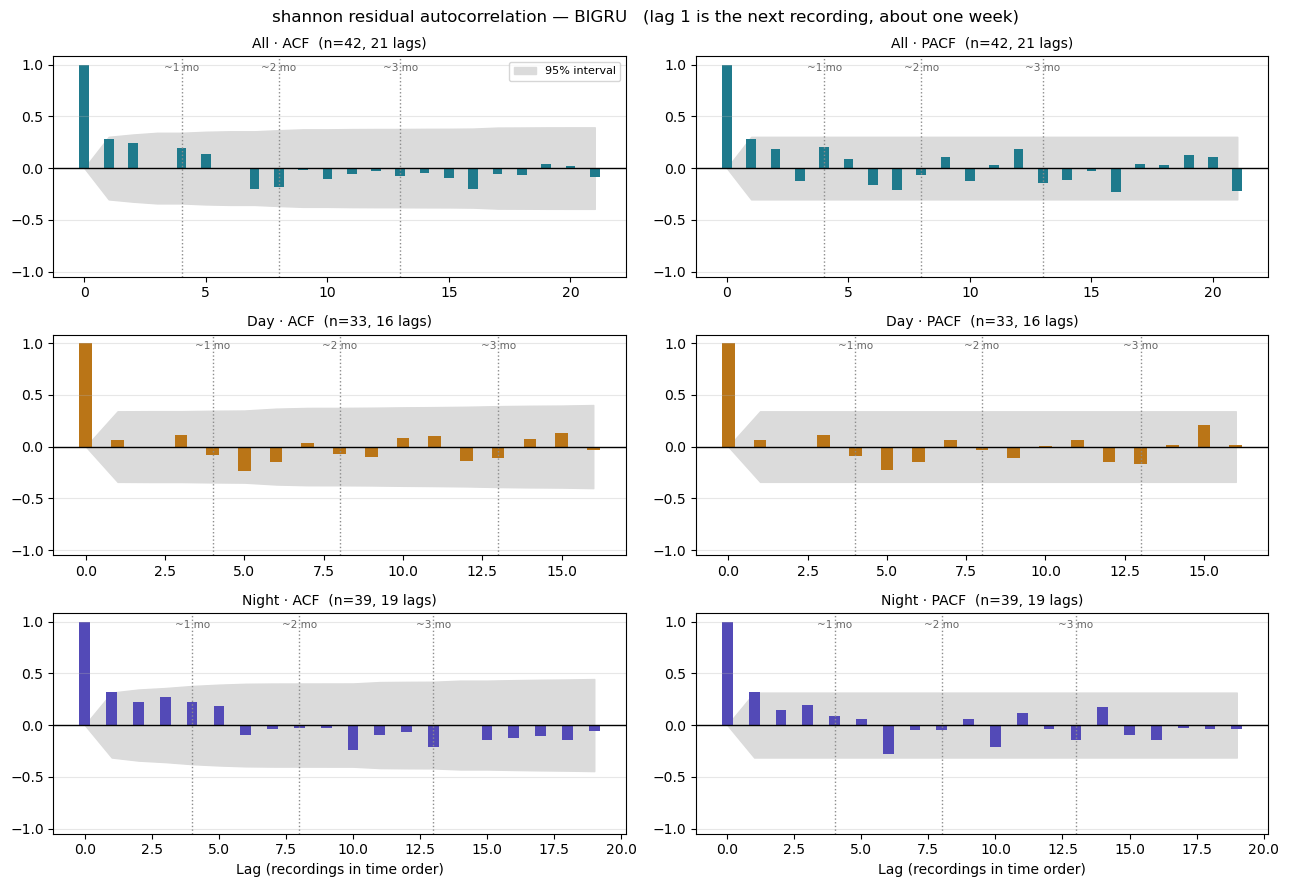

In [15]:
MONTH_LAGS = [(4, "~1 mo"), (8, "~2 mo"), (13, "~3 mo")]

def acf_ci(x, nlags, partial=False, alpha=0.05):
    """ACF or PACF with confidence intervals, on an evenly indexed series."""
    x = np.asarray(x, float)
    if partial:
        return pacf(x, nlags=nlags, alpha=alpha, method="ywm")
    return acf(x, nlags=nlags, alpha=alpha, fft=False)

rows = [w for w in ["All", "Day", "Night"] if len(SERIES[w]) >= 10]
fig, axes = plt.subplots(len(rows), 2, figsize=(13, 3.0*len(rows)), squeeze=False)
for r, w in enumerate(rows):
    s = SERIES[w]; n = len(s)
    nlags = max(4, min(n // 2, n - 2))
    for c, partial in [(0, False), (1, True)]:
        ax = axes[r, c]
        try:
            v, ci = acf_ci(s.values, nlags, partial)
        except Exception as e:
            ax.text(0.5, 0.5, str(e)[:60], ha="center", va="center",
                    transform=ax.transAxes, fontsize=8)
            ax.set_xticks([]); ax.set_yticks([]); continue
        lags = np.arange(len(v))
        ax.fill_between(lags, ci[:, 0] - v, ci[:, 1] - v, color="0.86", zorder=0,
                        label="95% interval")
        ax.bar(lags, v, width=0.4, color=COLS[w])
        for L, lab in MONTH_LAGS:
            if L < len(v):
                ax.axvline(L, color="0.55", ls=":", lw=1)
                ax.text(L, 1.02, lab, fontsize=7.5, color="0.4", ha="center", va="top")
        ax.axhline(0, color="k", lw=1)
        ax.set_ylim(-1.05, 1.08); ax.grid(axis="y", alpha=0.3)
        ax.set_title(f"{w} · {'PACF' if partial else 'ACF'}  (n={n}, {nlags} lags)", fontsize=10)
        if r == len(rows) - 1: ax.set_xlabel("Lag (recordings in time order)")
        if r == 0 and c == 0: ax.legend(fontsize=8, loc="upper right")
fig.suptitle(f"{tag} residual autocorrelation — {MODEL_NAME.upper()}   "
             f"(lag 1 is the next recording, about one week)", fontsize=12)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, f"acf_pacf_{tag}.png"), dpi=150, bbox_inches="tight")
plt.show()

The same series placed on a regular weekly calendar, as a check that the irregular spacing above is
not distorting anything. Missing weeks are left blank. If the two versions agree, the observation
ordering can be read at face value.

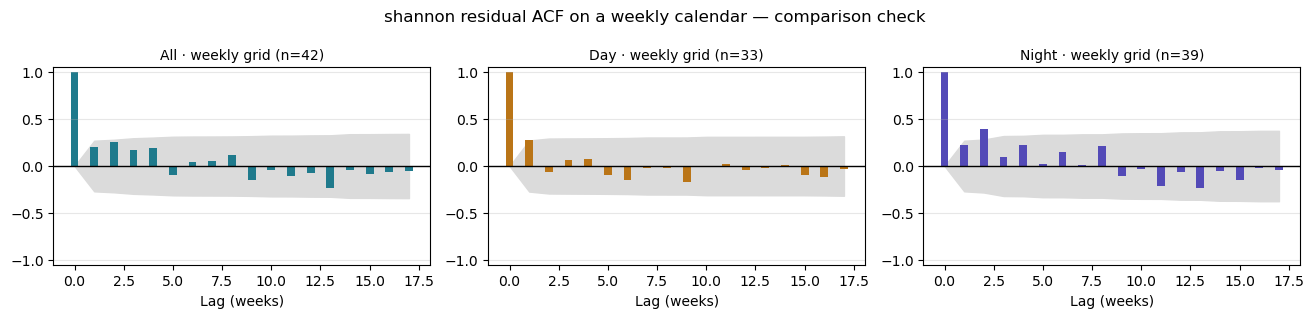

In [16]:
fig, axes = plt.subplots(1, len(rows), figsize=(4.4*len(rows), 3.2), squeeze=False)
for c, w in enumerate(rows):
    ax = axes[0, c]
    wk = SERIES[w].resample("W").mean()
    n = int(wk.notna().sum())
    nlags = max(4, min(len(wk) // 3, 20))
    try:
        v, ci = acf(wk.values, nlags=nlags, alpha=0.05, missing="conservative", fft=False)
    except Exception as e:
        ax.text(0.5, 0.5, str(e)[:50], ha="center", va="center",
                transform=ax.transAxes, fontsize=8); continue
    lags = np.arange(len(v))
    ax.fill_between(lags, ci[:, 0] - v, ci[:, 1] - v, color="0.86", zorder=0)
    ax.bar(lags, v, width=0.4, color=COLS[w])
    ax.axhline(0, color="k", lw=1); ax.set_ylim(-1.05, 1.05); ax.grid(axis="y", alpha=0.3)
    ax.set_title(f"{w} · weekly grid (n={n})", fontsize=10)
    ax.set_xlabel("Lag (weeks)")
fig.suptitle(f"{tag} residual ACF on a weekly calendar — comparison check", fontsize=12)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, f"acf_weekly_{tag}.png"), dpi=150, bbox_inches="tight")
plt.show()

Ljung-Box tests the same question formally: a small p-value means the residuals are not white noise.
The paired test asks separately whether the model is biased differently between day and night
sessions, which is a comparison rather than a lag.

In [17]:
lb = []
for w in rows:
    s = SERIES[w]
    lag = int(min(10, max(2, len(s) // 5)))
    try:
        rr = acorr_ljungbox(s.values, lags=[lag], return_df=True)
        lb.append(dict(series=w, n=len(s), lag=lag, stat=float(rr["lb_stat"].iloc[0]),
                       p=float(rr["lb_pvalue"].iloc[0])))
    except Exception as e:
        print(f"  {w}: {e}")
if lb:
    LB = pd.DataFrame(lb)
    LB["white_noise"] = np.where(LB["p"] > 0.05, "consistent", "REJECTED")
    with pd.option_context("display.float_format", lambda v: f"{v:.4f}"):
        print(LB.to_string(index=False))
    print("\nREJECTED means significant autocorrelation, i.e. time-indexed error.")

from scipy.stats import wilcoxon
pv = REC.dropna(subset=[RESID]).pivot_table(index="date", columns="collection",
                                            values=RESID).dropna()
if len(pv) >= 6 and {"day", "night"} <= set(pv.columns):
    st, pval = wilcoxon(pv["day"], pv["night"])
    print(f"\nday vs night, paired on {len(pv)} dates with both sessions:")
    print(f"   day mean {pv['day'].mean():+.4f} | night mean {pv['night'].mean():+.4f} "
          f"| difference {pv['day'].mean()-pv['night'].mean():+.4f} | Wilcoxon p = {pval:.4f}")
    print("   " + ("a systematic offset between the two session types" if pval < 0.05
                   else "no systematic offset between the two session types"))

series  n  lag    stat      p white_noise
   All 42    8 12.9796 0.1126  consistent
   Day 33    6  4.1072 0.6622  consistent
 Night 39    7 14.0979 0.0495    REJECTED

REJECTED means significant autocorrelation, i.e. time-indexed error.

day vs night, paired on 30 dates with both sessions:
   day mean -0.0159 | night mean +0.1043 | difference -0.1202 | Wilcoxon p = 0.0473
   a systematic offset between the two session types


## Files written

In [18]:
print(f"output table : {os.path.relpath(PRED_CSV, BASE)}")
print(f"charts       : {os.path.relpath(FIG_DIR, BASE)}/")
for f in sorted(os.listdir(FIG_DIR)):
    print(f"                 {f}")
print()
print(f"For the XGBoost step, use {PRED_COL} as an input feature. It is out-of-fold, so it can be")
print("combined with the other features without leakage, provided the tree model is evaluated on")
print("the same folds in runs/folds_k5_seed*.json.")
print()
print("Note: if notebook 03 is re-run, re-run this notebook so the output file stays in step")
print("with the regenerated feature table.")

output table : merged_features_with_pred.csv
charts       : figures/gru/
                 acf_pacf_shannon.png
                 acf_weekly_shannon.png
                 residuals_over_time_shannon.png

For the XGBoost step, use shannon_pred_gru as an input feature. It is out-of-fold, so it can be
combined with the other features without leakage, provided the tree model is evaluated on
the same folds in runs/folds_k5_seed*.json.

Note: if notebook 03 is re-run, re-run this notebook so the output file stays in step
with the regenerated feature table.
